In [ ]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt


In [ ]:
# Load dataset (update the file path as needed)
file_path = "/content/user_behavior_dataset.csv"
df = pd.read_csv(file_path)


In [ ]:
# Function to calculate Shannon Entropy
def shannon_entropy(data):
    value_counts = data.value_counts(normalize=True)
    return stats.entropy(value_counts)


In [ ]:
# Compute entropy for each column
entropy_scores = df.apply(shannon_entropy)

# Drop 'User ID' since it is not useful for clustering
entropy_scores = entropy_scores.drop(["User ID"], errors="ignore")


In [ ]:
# Select features with entropy above the median value
selected_features = entropy_scores[entropy_scores > entropy_scores.median()].index.tolist()

# Display selected features
print("Selected High-Entropy Features:", selected_features)


Selected High-Entropy Features: ['App Usage Time (min/day)', 'Screen On Time (hours/day)', 'Battery Drain (mAh/day)', 'Number of Apps Installed', 'Data Usage (MB/day)']


In [ ]:
# Extract selected features from the dataset
df_selected = df[selected_features]

# Normalize the features using StandardScaler
scaler = StandardScaler()
features_scaled = scaler.fit_transform(df_selected)


In [ ]:
df_selected.head()

,App Usage Time (min/day),Screen On Time (hours/day),Battery Drain (mAh/day),Number of Apps Installed,Data Usage (MB/day)
0,393,6.4,1872,67,1122
1,268,4.7,1331,42,944
2,154,4.0,761,32,322
3,239,4.8,1676,56,871
4,187,4.3,1367,58,988


In [ ]:
# Apply the Elbow Method to find the optimal number of clusters
wcss = []
max_clusters = 10

for i in range(1, max_clusters+1):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(features_scaled)
    wcss.append(kmeans.inertia_)


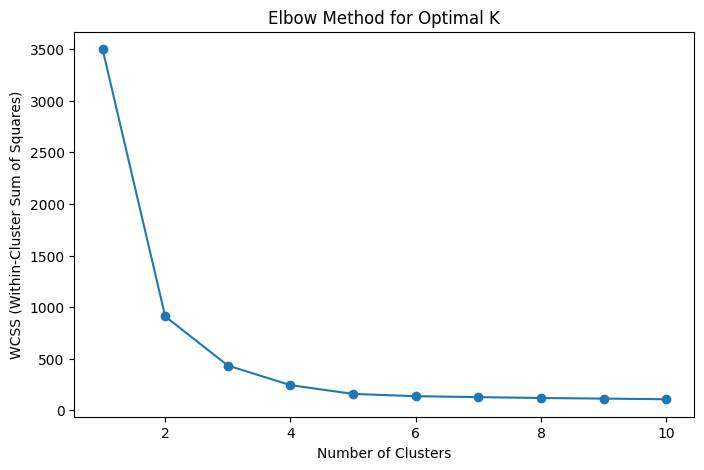

In [ ]:
# Plot the Elbow Method graph
plt.figure(figsize=(8, 5))
plt.plot(range(1, max_clusters+1), wcss, marker='o', linestyle='-')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.show()


In [ ]:
# Try k=3 and k=4 to find the best number of clusters
silhouette_scores = {}
for k in [3, 4]:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(features_scaled)
    score = silhouette_score(features_scaled, cluster_labels)
    silhouette_scores[k] = score

# Choose the best cluster number
optimal_k = max(silhouette_scores, key=silhouette_scores.get)
print("Optimal Number of Clusters:", optimal_k)


Optimal Number of Clusters: 4


In [ ]:
# Apply K-Means with the best k
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
df['Cluster'] = kmeans_final.fit_predict(features_scaled)


In [ ]:
# Save the final clustered data
clustered_file_path = "/content/clustered_user_data.csv"
df[['Cluster'] + selected_features].to_csv(clustered_file_path, index=False)

# Display the saved file path
print("Clustered data saved at:", clustered_file_path)


Clustered data saved at: /content/clustered_user_data.csv


In [ ]:
# Step 11: Save the overall clustered data (already done)
clustered_file_path = "/content/clustered_user_data.csv"
df[['Cluster'] + selected_features].to_csv(clustered_file_path, index=False)
print("Clustered data saved at:", clustered_file_path)

# Step 12: Separate the dataset into 4 different cluster files
for cluster_num in df['Cluster'].unique():  # Iterate through each unique cluster
    cluster_df = df[df['Cluster'] == cluster_num]  # Filter data for the specific cluster
    cluster_file_path = f"/content/cluster_{cluster_num}_data.csv"  # Define file name
    cluster_df[['Cluster'] + selected_features].to_csv(cluster_file_path, index=False)  # Save file
    print(f"Cluster {cluster_num} data saved at: {cluster_file_path}")


Clustered data saved at: /content/clustered_user_data.csv
Cluster 3 data saved at: /content/cluster_3_data.csv
Cluster 0 data saved at: /content/cluster_0_data.csv
Cluster 2 data saved at: /content/cluster_2_data.csv
Cluster 1 data saved at: /content/cluster_1_data.csv


In [ ]:
# Count the number of users in each cluster
cluster_counts = df['Cluster'].value_counts()

# Display the count of users per cluster
print("Number of users in each cluster:")
print(cluster_counts)


Number of users in each cluster:
Cluster
2    282
0    143
3    139
1    136
Name: count, dtype: int64


In [ ]:
# Group by Cluster and calculate mean for each feature
cluster_summary = df.groupby('Cluster')[selected_features].mean()

# Display the cluster behavior summary
print("Cluster Behavior Summary:\n", cluster_summary)


Cluster Behavior Summary:
          App Usage Time (min/day)  Screen On Time (hours/day)  \
Cluster                                                         
0                      235.398601                    4.955944   
1                      541.419118                   10.114706   
2                       97.468085                    2.291489   
3                      395.748201                    6.909353   

         Battery Drain (mAh/day)  Number of Apps Installed  \
Cluster                                                      
0                    1515.055944                 50.000000   
1                    2701.014706                 89.250000   
2                     676.996454                 22.943262   
3                    2105.805755                 69.920863   

         Data Usage (MB/day)  
Cluster                       
0                 822.013986  
1                1974.772059  
2                 331.287234  
3                1232.230216  


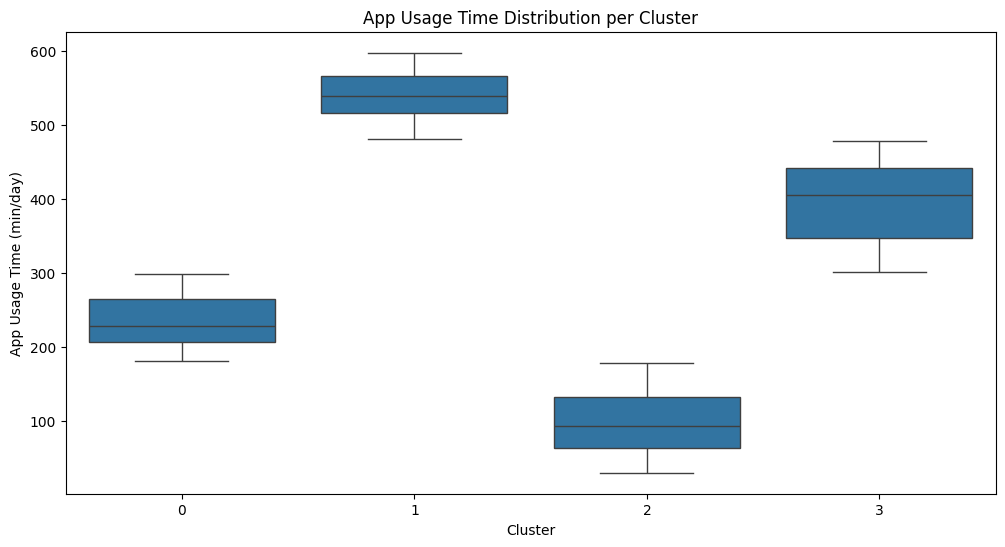

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the distribution of features for each cluster
plt.figure(figsize=(12, 6))
sns.boxplot(x=df['Cluster'], y=df['App Usage Time (min/day)'])
plt.title("App Usage Time Distribution per Cluster")
plt.show()


In [ ]:
pip install tensorflow


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler

# Load Clustered Data
df = pd.read_csv("clustered_user_data.csv")  # Update with your actual path

# Train Autoencoder on Cluster 0 & 2 (Normal Users)
df_cluster_0_2 = df[(df["Cluster"] == 0) | (df["Cluster"] == 2)]

# Select numerical features
train_data = df_cluster_0_2[["App Usage Time (min/day)", "Screen On Time (hours/day)",
                              "Battery Drain (mAh/day)", "Number of Apps Installed", "Data Usage (MB/day)"]].values

# Normalize the data
scaler = StandardScaler()
train_data_scaled = scaler.fit_transform(train_data)

# Define Autoencoder Model
input_dim = train_data_scaled.shape[1]  # Number of features
encoding_dim = 3  # Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='relu')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# Create Autoencoder model
autoencoder = Model(input_layer, decoded)
autoencoder.compile(optimizer='adam', loss='mse')

# Train Autoencoder on Normal Data (Cluster 0 & 2)
autoencoder.fit(train_data_scaled, train_data_scaled, epochs=50, batch_size=16, shuffle=True, verbose=1)

# Test Autoencoder on Full Clustered Data
test_data = df[["App Usage Time (min/day)", "Screen On Time (hours/day)",
                "Battery Drain (mAh/day)", "Number of Apps Installed", "Data Usage (MB/day)"]].values

test_data_scaled = scaler.transform(test_data)

# Compute reconstruction error
reconstructed_data = autoencoder.predict(test_data_scaled)
reconstruction_errors = np.mean(np.abs(reconstructed_data - test_data_scaled), axis=1)

# Add error scores to the dataframe
df["Reconstruction_Error"] = reconstruction_errors

# Lower the anomaly threshold (More sensitive detection)
threshold = np.percentile(reconstruction_errors, 60)  # Adjusted to 90th percentile

# Label anomalies (1 = Abnormal, 0 = Normal)
df["Anomaly"] = df["Reconstruction_Error"].apply(lambda x: 1 if x > threshold else 0)

# Save the results
df.to_csv("autoencoder_results_sensitive.csv", index=False)

print("✅ Autoencoder Training and Testing Completed! Results saved to 'autoencoder_results_sensitive.csv'")


Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 1.2913
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.1633
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.1166
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1.1899
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1.0405
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0118
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 1.0272
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.9837
Epoch 9/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8935
Epoch 10/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8662
Epoch 11/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.8714
Epoch 12/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7838
Epoch 13/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7947
Epoch 14/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.7602
Epoch 15/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.7073
Epoch 16/50
27/27 ━